# Maze RL v4 — PPO + CNN

Fixes vs v3:
- **Entropy floor**: adaptive entropy coef increases when entropy drops too low
- **LR annealing**: linear decay prevents catastrophic forgetting
- **Reward rebalance**: direction signal always present, not just for new cells
- **Early stopping on eval degradation** + model checkpointing

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from collections import deque
import hashlib, random, time, copy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda': print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## 1. Maze Generator

In [2]:
class DisjointSet:
    def __init__(self, n):
        self.parent = list(range(n)); self.size = [1]*n
    def find(self, x):
        r = x
        while r != self.parent[r]: r = self.parent[r]
        while x != r: self.parent[x], x = r, self.parent[x]
        return r
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            if self.size[ra] < self.size[rb]: ra, rb = rb, ra
            self.size[ra] += self.size[rb]; self.parent[rb] = ra

def make_maze(n=10):
    total = n*n
    edges = []
    for r in range(n):
        for c in range(n):
            nd = n*r+c
            if c<n-1: edges.append((nd, nd+1))
            if r<n-1: edges.append((nd, nd+n))
    random.shuffle(edges)
    ds = DisjointSet(total)
    tree = {c:[0,0,0,0] for c in range(total)}
    kept = []
    for c1,c2 in edges:
        if ds.find(c1) != ds.find(c2):
            ds.union(c1,c2)
            if c2==c1+1:   tree[c1][1]=1; tree[c2][3]=1
            elif c2==c1+n: tree[c1][2]=1; tree[c2][0]=1
            kept.append((c1,c2))
    sz = 2*n+1
    grid = np.zeros((sz,sz), dtype=np.int32)
    for i in range(n):
        for j in range(n):
            y,x,nd = 2*i+1,2*j+1,i*n+j
            grid[y,x]=1
            if j+1<n and tree[nd][1]: grid[y,x+1]=1
            if i+1<n and tree[nd][2]: grid[y+1,x]=1
    grid[1,0] = grid[-2,-1] = 1
    return grid, kept

def generate_mazes(n, maze_size=10):
    result, hashes = [], set()
    while len(result) < n:
        maze, edges = make_maze(maze_size)
        key = hashlib.sha256(str(sorted(edges)).encode()).hexdigest()
        if key not in hashes:
            hashes.add(key); result.append(maze)
            if len(result)%500==0: print(f'  {len(result)}/{n}')
    return np.stack(result)

print('Generator OK')

Generator OK


## 2. BFS + Environment

In [3]:
def bfs_distance_map(maze):
    H,W = maze.shape
    dist = np.full((H,W), 9999.0, dtype=np.float32)
    end = (19,20); dist[end]=0; q=deque([end])
    while q:
        r,c = q.popleft()
        for dr,dc in [(1,0),(0,1),(-1,0),(0,-1)]:
            nr,nc = r+dr,c+dc
            if 0<=nr<H and 0<=nc<W and maze[nr,nc]==1 and dist[nr,nc]>9000:
                dist[nr,nc]=dist[r,c]+1; q.append((nr,nc))
    return dist

def bfs_shortest_path(maze):
    H,W = maze.shape
    start,end = (1,0),(19,20)
    prev = {start:None}; q=deque([start])
    while q:
        r,c = q.popleft()
        if (r,c)==end: break
        for dr,dc in [(1,0),(0,1),(-1,0),(0,-1)]:
            nr,nc = r+dr,c+dc
            if 0<=nr<H and 0<=nc<W and maze[nr,nc]==1 and (nr,nc) not in prev:
                prev[(nr,nc)]=(r,c); q.append((nr,nc))
    mask = np.zeros((H,W), dtype=np.float32)
    cell = end
    if cell not in prev: return mask
    while cell is not None: mask[cell]=1.0; cell=prev[cell]
    return mask

def precompute(mazes):
    n = len(mazes)
    dists = np.zeros_like(mazes, dtype=np.float32)
    sps = np.zeros_like(mazes, dtype=np.float32)
    for i in range(n):
        dists[i] = bfs_distance_map(mazes[i])
        sps[i] = bfs_shortest_path(mazes[i])
    return dists, sps


class VecMazeEnv:
    """
    Vectorized Maze Environment (numpy-only).
    Obs: (N, 4, 21, 21) — maze, agent, exit, visited
    Actions: 0=down, 1=right, 2=up, 3=left
    """
    GS=21; ER,EC=1,0; XR,XC=19,20
    DR=np.array([1,0,-1,0],dtype=np.int32)
    DC=np.array([0,1,0,-1],dtype=np.int32)

    def __init__(self, pool, n_envs, max_steps=400, stage=1,
                 dist_pool=None, sp_pool=None):
        self.pool=pool.astype(np.float32)
        self.n_envs=n_envs; self.max_steps=max_steps; self.stage=stage
        self.dist_pool=dist_pool; self.sp_pool=sp_pool
        N,G = n_envs,self.GS
        self.mazes=np.zeros((N,G,G),dtype=np.float32)
        self.dists=np.zeros((N,G,G),dtype=np.float32)
        self.sps=np.zeros((N,G,G),dtype=np.float32)
        self.pos_r=np.zeros(N,dtype=np.int32); self.pos_c=np.zeros(N,dtype=np.int32)
        self.steps=np.zeros(N,dtype=np.int32)
        self.visited=np.zeros((N,G,G),dtype=np.float32)
        self.done=np.zeros(N,dtype=bool)

    def reset(self, idx=None):
        if idx is None: idx=np.arange(self.n_envs)
        n=len(idx); mi=np.random.randint(0,len(self.pool),size=n)
        self.mazes[idx]=self.pool[mi]
        if self.dist_pool is not None: self.dists[idx]=self.dist_pool[mi]
        if self.sp_pool is not None: self.sps[idx]=self.sp_pool[mi]
        self.pos_r[idx]=self.ER; self.pos_c[idx]=self.EC
        self.steps[idx]=0; self.visited[idx]=0.0
        self.visited[idx,self.ER,self.EC]=1.0; self.done[idx]=False
        return self._obs()

    def step(self, actions):
        I=np.arange(self.n_envs); alive=~self.done
        old_r,old_c = self.pos_r.copy(), self.pos_c.copy()

        nr=np.clip(self.pos_r+self.DR[actions],0,self.GS-1)
        nc=np.clip(self.pos_c+self.DC[actions],0,self.GS-1)
        walk=self.mazes[I,nr,nc]>0.5; valid=alive&walk
        self.pos_r=np.where(valid,nr,self.pos_r)
        self.pos_c=np.where(valid,nc,self.pos_c)

        was_vis=self.visited[I,self.pos_r,self.pos_c].copy()
        self.visited[I,self.pos_r,self.pos_c]=1.0
        is_new=(was_vis<0.5)&alive
        is_revisit=(was_vis>0.5)&alive&valid
        stayed=(self.pos_r==old_r)&(self.pos_c==old_c)&alive

        self.steps+=alive.astype(np.int32)
        reached=(self.pos_r==self.XR)&(self.pos_c==self.XC)&alive
        timeout=(self.steps>=self.max_steps)&alive&~reached

        rew=np.zeros(self.n_envs,dtype=np.float32)
        al=alive.astype(np.float32)
        d_old=self.dists[I,old_r,old_c]; d_new=self.dists[I,self.pos_r,self.pos_c]
        closer=((d_old-d_new)>0.5).astype(np.float32)*al
        farther=((d_new-d_old)>0.5).astype(np.float32)*al

        if self.stage==1:
            rew += is_new.astype(np.float32)*1.0
            rew += closer*0.3
            rew -= farther*0.15
            rew -= stayed.astype(np.float32)*0.3
            rew -= is_revisit.astype(np.float32)*0.05
            rew += reached.astype(np.float32)*20.0
        elif self.stage==2:
            rew += closer*1.0
            rew -= farther*0.5
            rew -= stayed.astype(np.float32)*0.5
            rew -= is_revisit.astype(np.float32)*0.15
            rew -= al*0.01
            rew += reached.astype(np.float32)*20.0
            rew -= timeout.astype(np.float32)*2.0
        elif self.stage==3:
            on_sp=self.sps[I,self.pos_r,self.pos_c]
            off_sp=(1.0-on_sp)*al
            rew += closer*1.0
            rew -= farther*0.5
            rew -= stayed.astype(np.float32)*0.5
            rew -= off_sp*0.5
            rew += on_sp*al*0.2
            rew -= al*0.01
            rew += reached.astype(np.float32)*20.0
            rew -= timeout.astype(np.float32)*2.0

        self.done=self.done|reached|timeout
        return self._obs(), rew, self.done.copy(), {
            'reached_exit':reached,'timeout':timeout,'steps':self.steps.copy()}

    def _obs(self):
        obs=np.zeros((self.n_envs,4,self.GS,self.GS),dtype=np.float32)
        obs[:,0]=self.mazes
        I=np.arange(self.n_envs)
        obs[I,1,self.pos_r,self.pos_c]=1.0
        obs[:,2,self.XR,self.XC]=1.0
        obs[:,3]=self.visited
        return obs

    def auto_reset_done(self):
        di=np.where(self.done)[0]
        if len(di)>0: self.reset(di)
        return self._obs()

print('Env OK')

Env OK


## 3. CNN Actor-Critic

In [4]:
class MazeCNN(nn.Module):
    def __init__(self, in_ch=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.fc = nn.Sequential(nn.Linear(128*3*3, 256), nn.ReLU())
        self.pi = nn.Linear(256, 4)
        self.vf = nn.Linear(256, 1)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.pi.weight, gain=0.01)

    def forward(self, x):
        f = self.conv(x).reshape(x.size(0), -1)
        return self.pi(self.fc(f)), self.vf(self.fc(f)).squeeze(-1)

    def act(self, obs, action=None):
        logits, val = self.forward(obs)
        dist = Categorical(logits=logits)
        if action is None: action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), val

    def get_value(self, obs):
        return self.forward(obs)[1]

model = MazeCNN().to(device)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Params: 426,917


## 4. PPO with entropy floor & LR annealing

In [5]:
class RolloutBuffer:
    def __init__(self, n_steps, n_envs, obs_shape, dev):
        self.n_steps,self.n_envs,self.dev = n_steps,n_envs,dev
        S=(n_steps,n_envs)
        self.obs=np.zeros((n_steps,n_envs,*obs_shape),dtype=np.float32)
        self.actions=np.zeros(S,dtype=np.int64)
        self.log_probs=np.zeros(S,dtype=np.float32)
        self.rewards=np.zeros(S,dtype=np.float32)
        self.dones=np.zeros(S,dtype=np.float32)
        self.values=np.zeros(S,dtype=np.float32)
        self.ptr=0
    def store(self,obs,act,lp,rew,done,val):
        self.obs[self.ptr]=obs; self.actions[self.ptr]=act
        self.log_probs[self.ptr]=lp; self.rewards[self.ptr]=rew
        self.dones[self.ptr]=done; self.values[self.ptr]=val; self.ptr+=1
    def reset(self): self.ptr=0
    def compute_gae(self,last_val,last_done,gamma=0.99,lam=0.95):
        adv=np.zeros_like(self.rewards); gae=0.0
        for t in reversed(range(self.n_steps)):
            nv=last_val if t==self.n_steps-1 else self.values[t+1]
            nd=last_done if t==self.n_steps-1 else self.dones[t+1]
            delta=self.rewards[t]+gamma*nv*(1-nd)-self.values[t]
            gae=delta+gamma*lam*(1-nd)*gae; adv[t]=gae
        return adv, adv+self.values
    def batches(self,adv,ret,bs):
        T=self.n_steps*self.n_envs; idx=np.random.permutation(T)
        flat=lambda x: x.reshape(T) if x.ndim==2 else x.reshape(T,*x.shape[2:])
        O,A,L,V,AD,R=[flat(x) for x in [self.obs,self.actions,self.log_probs,self.values,adv,ret]]
        for s in range(0,T,bs):
            i=idx[s:s+bs]
            yield (torch.tensor(O[i],device=self.dev),torch.tensor(A[i],device=self.dev),
                   torch.tensor(L[i],device=self.dev),torch.tensor(V[i],device=self.dev),
                   torch.tensor(AD[i],device=self.dev),torch.tensor(R[i],device=self.dev))


class PPO:
    """
    PPO с:
    - Adaptive entropy coefficient (поднимается если entropy < target)
    - Linear LR annealing
    """
    def __init__(self, model, lr=3e-4, gamma=0.99, lam=0.95, eps=0.2,
                 ent_coef=0.01, val_coef=0.5, epochs=4, bs=512,
                 target_entropy=0.6, total_iters=600):
        self.model=model; self.gamma=gamma; self.lam=lam; self.eps=eps
        self.base_ent_coef=ent_coef; self.ent_coef=ent_coef
        self.val_coef=val_coef; self.epochs=epochs; self.bs=bs
        self.target_entropy=target_entropy
        self.lr_start=lr; self.total_iters=total_iters
        self.opt = optim.Adam(model.parameters(), lr=lr, eps=1e-5)
        self.current_iter = 0

    def _anneal_lr(self):
        """Linear LR decay."""
        frac = 1.0 - self.current_iter / self.total_iters
        frac = max(frac, 0.1)  # don't go below 10% of initial LR
        lr = self.lr_start * frac
        for pg in self.opt.param_groups:
            pg['lr'] = lr
        return lr

    def update(self, buf, last_val, last_done):
        self.current_iter += 1
        lr = self._anneal_lr()
        
        adv, ret = buf.compute_gae(last_val, last_done, self.gamma, self.lam)
        adv = (adv-adv.mean())/(adv.std()+1e-8)
        st={'pl':0,'vl':0,'ent':0,'cf':0}; nu=0
        
        for _ in range(self.epochs):
            for obs,act,old_lp,old_v,ad,rt in buf.batches(adv,ret,self.bs):
                _,new_lp,ent,new_v = self.model.act(obs,act)
                ratio = (new_lp-old_lp).exp()
                s1,s2 = ratio*ad, ratio.clamp(1-self.eps,1+self.eps)*ad
                pl = -torch.min(s1,s2).mean()
                vc = old_v+(new_v-old_v).clamp(-self.eps,self.eps)
                vl = 0.5*torch.max((new_v-rt)**2,(vc-rt)**2).mean()
                
                # Entropy loss with adaptive coefficient
                ent_mean = ent.mean()
                loss = pl + self.val_coef*vl - self.ent_coef*ent_mean
                
                self.opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                self.opt.step()
                with torch.no_grad():
                    st['pl']+=pl.item(); st['vl']+=vl.item()
                    st['ent']+=ent_mean.item()
                    st['cf']+=((ratio-1).abs()>self.eps).float().mean().item()
                    nu+=1
        
        avg_ent = st['ent']/nu
        
        # Adaptive entropy: if entropy drops below target, boost coef
        if avg_ent < self.target_entropy:
            self.ent_coef = min(self.ent_coef * 1.05, self.base_ent_coef * 5)
        else:
            self.ent_coef = max(self.ent_coef * 0.99, self.base_ent_coef)
        
        stats = {k:v/nu for k,v in st.items()}
        stats['lr'] = lr
        stats['ent_coef'] = self.ent_coef
        return stats

    def collect(self, env, buf, obs):
        buf.reset(); ep_infos=[]
        for _ in range(buf.n_steps):
            with torch.no_grad():
                t=torch.tensor(obs,device=device)
                act,lp,_,val=self.model.act(t)
            a,l,v=act.cpu().numpy(),lp.cpu().numpy(),val.cpu().numpy()
            nobs,rew,done,info=env.step(a)
            buf.store(obs,a,l,rew,done.astype(np.float32),v)
            for i in range(env.n_envs):
                if info['reached_exit'][i] or info['timeout'][i]:
                    ep_infos.append({'exit':bool(info['reached_exit'][i]),
                                     'steps':int(info['steps'][i])})
            obs=env.auto_reset_done()
        return obs, ep_infos

print('PPO OK')

PPO OK


## 5. Data

In [6]:
N_TRAIN, N_EVAL = 1000, 200
print(f'Generating {N_TRAIN} train mazes...')
train_mazes = generate_mazes(N_TRAIN, 10)
print(f'Generating {N_EVAL} eval mazes...')
eval_mazes = generate_mazes(N_EVAL, 10)
print('BFS precompute...')
train_dist, train_sp = precompute(train_mazes)
eval_dist, eval_sp = precompute(eval_mazes)
print(f'Avg shortest path: {train_sp.sum(axis=(1,2)).mean():.0f} cells')
print(f'Avg BFS entry->exit: {train_dist[:,1,0].mean():.0f}')

Generating 1000 train mazes...
  500/1000
  1000/1000
Generating 200 eval mazes...
BFS precompute...
Avg shortest path: 49 cells
Avg BFS entry->exit: 48


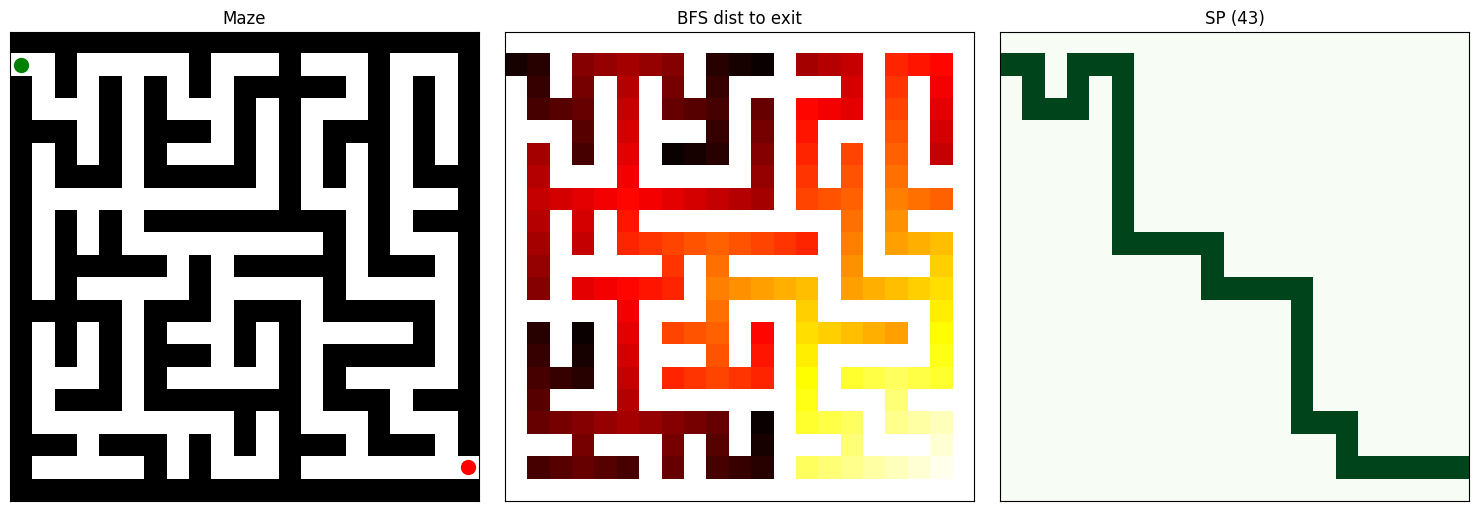

In [7]:
fig,axes=plt.subplots(1,3,figsize=(15,5))
i=0
axes[0].imshow(train_mazes[i],cmap='binary_r'); axes[0].set_title('Maze')
axes[0].plot(0,1,'go',ms=10); axes[0].plot(20,19,'ro',ms=10)
d=train_dist[i].copy(); d[d>500]=np.nan
axes[1].imshow(d,cmap='hot_r'); axes[1].set_title('BFS dist to exit')
axes[2].imshow(train_sp[i],cmap='Greens'); axes[2].set_title(f'SP ({int(train_sp[i].sum())})')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. Training

In [8]:
def evaluate_model(model, mazes, dists, sps, stage, n=200, ms=400, n_runs=3):
    total_r, total_s, total_rc = 0, 0, 0
    for _ in range(n_runs):
        env=VecMazeEnv(mazes,n,ms,stage,dists,sps)
        obs=env.reset()
        reached=np.zeros(n,dtype=bool); steps_a=np.zeros(n,dtype=np.int32)
        done_f=np.zeros(n,dtype=bool)
        for _ in range(ms):
            with torch.no_grad():
                actions,_,_,_ = model.act(torch.tensor(obs,device=device))
                actions=actions.cpu().numpy()
            obs,_,_,info = env.step(actions)
            for i in range(n):
                if (info['reached_exit'][i] or info['timeout'][i]) and not done_f[i]:
                    reached[i]=info['reached_exit'][i]; steps_a[i]=info['steps'][i]
                    done_f[i]=True
            if done_f.all(): break
        total_r+=reached.sum()
        if reached.any(): total_s+=steps_a[reached].sum(); total_rc+=reached.sum()
    sr = total_r/(n*n_runs)
    avg_s = total_s/total_rc if total_rc>0 else ms
    return sr, avg_s

def plot_curves(hist,title):
    fig,axes=plt.subplots(1,4,figsize=(18,3.5))
    for ax,key,lab in zip(axes,['exit_rate','avg_steps','pl','ent'],
        ['Train Exit Rate','Avg Steps','Policy Loss','Entropy']):
        data=hist[key]; ax.plot(data,alpha=0.3,color='C0')
        w=min(30,max(1,len(data)//5))
        if len(data)>w:
            sm=np.convolve(data,np.ones(w)/w,'valid')
            ax.plot(range(w-1,len(data)),sm,'C0',lw=2)
        ax.set_title(lab); ax.grid(True,alpha=0.3); ax.set_xlabel('Iter')
    if hist.get('eval_sr'):
        ax2=axes[0].twinx()
        ax2.plot(hist['eval_iter'],hist['eval_sr'],'r*-',ms=8,label='Eval SR')
        ax2.set_ylabel('Eval SR',color='r'); ax2.legend(loc='lower right')
    fig.suptitle(title,fontsize=13); plt.tight_layout(); plt.show()

In [9]:
N_ENVS     = 64
N_STEPS    = 512
MAX_STEPS  = 400
GAMMA      = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS   = 0.2
VAL_COEF   = 0.5
N_EPOCHS   = 4
BATCH_SIZE = 512

STAGES = {
    1: {'name':'Exploration',   'iters':800,  'lr':3e-4, 'ent':0.05, 'target_ent':0.7},
    2: {'name':'Goal-seeking',  'iters':1000, 'lr':2e-4, 'ent':0.03, 'target_ent':0.5},
    3: {'name':'Shortest path', 'iters':1000, 'lr':1e-4, 'ent':0.02, 'target_ent':0.4},
}

In [10]:
def train_stage(stage, model):
    cfg=STAGES[stage]; n_iter=cfg['iters']
    print(f"\n{'='*60}")
    print(f"  STAGE {stage}: {cfg['name']}")
    print(f"  iters={n_iter}, lr={cfg['lr']}, ent={cfg['ent']}, target_ent={cfg['target_ent']}")
    print(f"{'='*60}")

    env=VecMazeEnv(train_mazes,N_ENVS,MAX_STEPS,stage,train_dist,train_sp)
    ppo=PPO(model,cfg['lr'],GAMMA,GAE_LAMBDA,CLIP_EPS,
            cfg['ent'],VAL_COEF,N_EPOCHS,BATCH_SIZE,
            target_entropy=cfg['target_ent'], total_iters=n_iter)
    buf=RolloutBuffer(N_STEPS,N_ENVS,(4,21,21),device)
    obs=env.reset()

    hist={'exit_rate':[],'avg_steps':[],'pl':[],'ent':[],'eval_sr':[],'eval_iter':[]}
    log_every=max(1,n_iter//30)
    eval_every=max(1,n_iter//10)
    t0=time.time()
    best_sr=0
    best_state=None
    patience_counter = 0
    patience_limit = 3  # eval checks without improvement before stopping

    for it in range(1, n_iter+1):
        obs,eps = ppo.collect(env,buf,obs)
        with torch.no_grad():
            lv=model.get_value(torch.tensor(obs,device=device)).cpu().numpy()
        m = ppo.update(buf,lv,env.done.astype(np.float32))

        exits=sum(1 for e in eps if e['exit'])
        er=exits/max(len(eps),1)
        avg_s=np.mean([e['steps'] for e in eps]) if eps else MAX_STEPS
        hist['exit_rate'].append(er)
        hist['avg_steps'].append(avg_s)
        hist['pl'].append(m['pl'])
        hist['ent'].append(m['ent'])

        if it%log_every==0:
            fps=(it*N_STEPS*N_ENVS)/(time.time()-t0)
            print(f"  {it:4d}/{n_iter} | Exit:{er:.0%} | Steps:{avg_s:.0f} | "
                  f"PL:{m['pl']:.4f} | Ent:{m['ent']:.3f} | "
                  f"EntC:{m['ent_coef']:.4f} | LR:{m['lr']:.1e} | FPS:{fps:.0f}")

        if it%eval_every==0:
            sr,avs = evaluate_model(model,eval_mazes,eval_dist,eval_sp,stage)
            hist['eval_sr'].append(sr); hist['eval_iter'].append(it)
            improved = sr > best_sr + 0.01
            if improved:
                best_sr=sr
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
                print(f"  >>> EVAL: Success={sr:.1%}, Steps={avs:.1f} *** BEST")
            else:
                patience_counter += 1
                print(f"  >>> EVAL: Success={sr:.1%}, Steps={avs:.1f} (patience {patience_counter}/{patience_limit})")
            
            # If we had a good model and it degraded, restore best
            if patience_counter >= patience_limit and best_state is not None and best_sr > 0.3:
                print(f"  >>> Restoring best model (sr={best_sr:.1%}) and continuing with lower LR")
                model.load_state_dict(best_state)
                # Cut LR in half
                ppo.lr_start *= 0.5
                patience_counter = 0

    # Load best model at the end
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  Loaded best checkpoint (sr={best_sr:.1%})")

    sr,avs = evaluate_model(model,eval_mazes,eval_dist,eval_sp,stage)
    print(f"\n  Final: Success={sr:.1%}, Steps={avs:.1f}")
    plot_curves(hist, f'Stage {stage}: {cfg["name"]}')
    return model

### Stage 1: Exploration

In [ ]:
model = MazeCNN().to(device)
model = train_stage(1, model)


  STAGE 1: Exploration
  iters=800, lr=0.0003, ent=0.05, target_ent=0.7
    26/800 | Exit:2% | Steps:396 | PL:-0.0110 | Ent:1.148 | EntC:0.0500 | LR:2.9e-04 | FPS:1235
    52/800 | Exit:56% | Steps:256 | PL:-0.0047 | Ent:0.904 | EntC:0.0500 | LR:2.8e-04 | FPS:1310
    78/800 | Exit:46% | Steps:292 | PL:-0.0054 | Ent:0.849 | EntC:0.0500 | LR:2.7e-04 | FPS:1324
  >>> EVAL: Success=29.3%, Steps=163.8 *** BEST
   104/800 | Exit:17% | Steps:367 | PL:-0.0054 | Ent:0.813 | EntC:0.0500 | LR:2.6e-04 | FPS:1321
   130/800 | Exit:13% | Steps:370 | PL:-0.0055 | Ent:0.888 | EntC:0.0500 | LR:2.5e-04 | FPS:1317
   156/800 | Exit:1% | Steps:398 | PL:-0.0039 | Ent:0.803 | EntC:0.0500 | LR:2.4e-04 | FPS:1316
  >>> EVAL: Success=6.3%, Steps=210.5 (patience 1/3)
   182/800 | Exit:2% | Steps:395 | PL:-0.0038 | Ent:0.812 | EntC:0.0500 | LR:2.3e-04 | FPS:1315
   208/800 | Exit:11% | Steps:373 | PL:-0.0066 | Ent:0.747 | EntC:0.0500 | LR:2.2e-04 | FPS:1315
   234/800 | Exit:4% | Steps:391 | PL:-0.0036 | Ent:0

### Stage 2: Goal-seeking

In [ ]:
model = train_stage(2, model)

### Stage 3: Shortest path

In [ ]:
model = train_stage(3, model)

## 7. Final evaluation

In [ ]:
print('='*60)
print('  FINAL EVALUATION')
print('='*60)
for st in [1,2,3]:
    sr,avs = evaluate_model(model,eval_mazes,eval_dist,eval_sp,st)
    print(f'  Stage {st}: Success={sr:.1%}, Avg steps={avs:.1f}')

## 8. Visualization

In [ ]:
def visualize_solution(model, maze, sp_mask, max_steps=400):
    mf=maze.astype(np.float32); r,c=1,0; path=[(r,c)]
    visited=np.zeros((21,21),dtype=np.float32); visited[r,c]=1.0
    for _ in range(max_steps):
        if r==19 and c==20: break
        obs=np.zeros((1,4,21,21),dtype=np.float32)
        obs[0,0]=mf; obs[0,1,r,c]=1.0; obs[0,2,19,20]=1.0; obs[0,3]=visited
        with torch.no_grad():
            actions,_,_,_=model.act(torch.tensor(obs,device=device))
            action=actions.item()
        dr=[1,0,-1,0][action]; dc=[0,1,0,-1][action]
        nr,nc=r+dr,c+dc
        if 0<=nr<21 and 0<=nc<21 and maze[nr,nc]==1: r,c=nr,nc
        visited[r,c]=1.0; path.append((r,c))
    reached=(r==19 and c==20)
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    img=np.stack([maze.astype(float)]*3,axis=-1)
    for pr,pc in path: img[pr,pc]=[1,0.3,0.3]
    img[1,0]=[0,1,0]; img[19,20]=[0,0,1]; axes[0].imshow(img)
    axes[0].set_title(f"Path ({len(path)} steps) — {'OK' if reached else 'FAIL'}")
    img2=np.stack([maze.astype(float)]*3,axis=-1)
    for ri,ci in zip(*np.where(sp_mask>0)): img2[ri,ci]=[0.3,1,0.3]
    for pr,pc in path:
        img2[pr,pc]=[0.3,0.3,1] if sp_mask[pr,pc]>0.5 else [1,0.3,0.3]
    axes[1].imshow(img2); axes[1].set_title(f'vs SP ({int(sp_mask.sum())})')
    axes[1].legend(handles=[
        mpatches.Patch(color=(0.3,1,0.3),label='SP'),
        mpatches.Patch(color=(0.3,0.3,1),label='On SP'),
        mpatches.Patch(color=(1,0.3,0.3),label='Off SP'),
    ],loc='lower right',fontsize=8)
    for ax in axes: ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

for _ in range(6):
    i=np.random.randint(len(eval_mazes))
    visualize_solution(model,eval_mazes[i],eval_sp[i])

In [ ]:
torch.save(model.state_dict(),'maze_solver_v4.pt')
print('Saved!')